# 🚦 04 — TẮC ĐƯỜNG (Traffic) · bộ TP.HCM

**Đây là phần Boston KHÔNG làm được** (thiếu cột thời lượng → chỉ thấy "sàn nhiễu ~2 USD").
Bộ HCM có `quote_duration` → đo tắc đường trực tiếp và tác động của nó tới giá & hệ số nhân.

> Đo tắc đường bằng: `speed_kmh` (tốc độ, thấp=tắc) và `dur_per_km` (phút/km, cao=tắc).

In [1]:
import sys; sys.path.insert(0, ".")
from _common import *
setup()
df = load(frac=0.15)   # doi frac=1.0 de nap toan bo

Nap 1,034,550 dong (mau 15%) | gia median 114k VND | surge 81.7%


## 1. Phân bố thời lượng, tốc độ, mức tắc

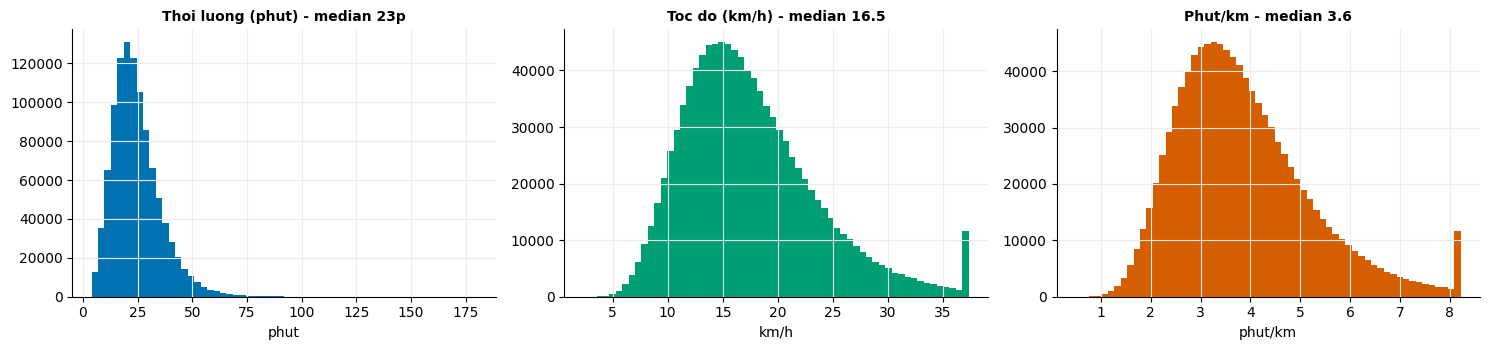

In [2]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
ax[0].hist(df.quote_duration/60, bins=60, color=BLUE); ax[0].set_title(f"Thoi luong (phut) - median {df.quote_duration.median()/60:.0f}p", fontweight="bold", fontsize=10); ax[0].set_xlabel("phut")
ax[1].hist(df.speed_kmh.clip(0, df.speed_kmh.quantile(.99)), bins=60, color=GREEN); ax[1].set_title(f"Toc do (km/h) - median {df.speed_kmh.median():.1f}", fontweight="bold", fontsize=10); ax[1].set_xlabel("km/h")
ax[2].hist(df.dur_per_km.clip(0, df.dur_per_km.quantile(.99)), bins=60, color=RED); ax[2].set_title(f"Phut/km - median {df.dur_per_km.median():.1f}", fontweight="bold", fontsize=10); ax[2].set_xlabel("phut/km")
plt.tight_layout(); plt.show()

## 2. ⭐ Tắc đường làm tăng giá — kiểm soát quãng đường

Câu hỏi cốt lõi: **cùng một quãng đường**, chuyến tắc hơn (thời lượng dài) có đắt hơn không?

corr(quang duong, gia) = 0.689
corr(thoi luong, gia)  = 0.697



corr(thoi luong, gia) TRONG cung dai quang duong (kiem soat) = 0.484
-> > 0 ro rang: TAC DUONG lam tang gia doc lap quang duong (cuoc tinh theo phut).


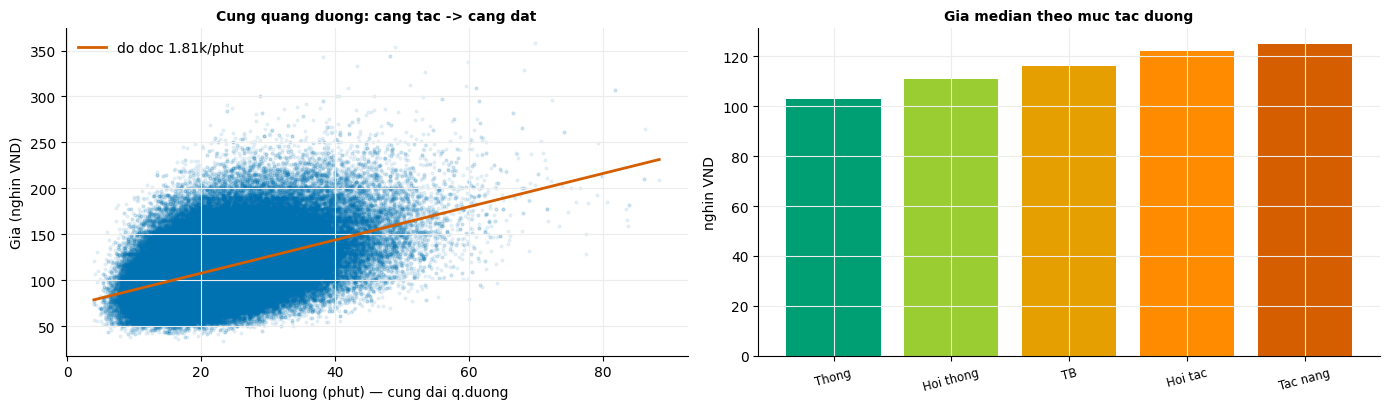

In [3]:
print(f"corr(quang duong, gia) = {df.quote_distance.corr(df[PRICE]):.3f}")
print(f"corr(thoi luong, gia)  = {df.quote_duration.corr(df[PRICE]):.3f}")
r_ctrl = control_distance_corr(df, "quote_duration", PRICE)
print(f"\ncorr(thoi luong, gia) TRONG cung dai quang duong (kiem soat) = {r_ctrl:.3f}")
print("-> > 0 ro rang: TAC DUONG lam tang gia doc lap quang duong (cuoc tinh theo phut).")

# truc quan: cung dai quang duong pho bien
mid = df.quote_distance.median()
band = df[(df.quote_distance>mid*0.9)&(df.quote_distance<mid*1.1)]
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
ax[0].scatter(band.quote_duration/60, band.price_k, s=4, alpha=.08, color=BLUE)
z=np.polyfit(band.quote_duration/60, band.price_k,1); xs=np.linspace((band.quote_duration/60).min(),(band.quote_duration/60).max(),50)
ax[0].plot(xs,np.polyval(z,xs),color=RED,lw=2,label=f"do doc {z[0]:.2f}k/phut")
ax[0].set_xlabel("Thoi luong (phut) — cung dai q.duong"); ax[0].set_ylabel("Gia (nghin VND)")
ax[0].set_title("Cung quang duong: cang tac -> cang dat", fontweight="bold", fontsize=10); ax[0].legend(frameon=False)
df["tacbin"] = pd.qcut(df.dur_per_km, 5, labels=["Thong","Hoi thong","TB","Hoi tac","Tac nang"], duplicates="drop")
g = df.groupby("tacbin").price_k.median()
ax[1].bar(range(len(g)), g.values, color=[GREEN,"#9ACD32",ORANGE,"#FF8C00",RED][:len(g)])
ax[1].set_xticks(range(len(g))); ax[1].set_xticklabels(g.index, rotation=15, fontsize=8.5)
ax[1].set_title("Gia median theo muc tac duong", fontweight="bold", fontsize=10); ax[1].set_ylabel("nghin VND")
plt.tight_layout(); plt.show()

## 3. Khi nào tắc nhất? (tốc độ theo giờ)

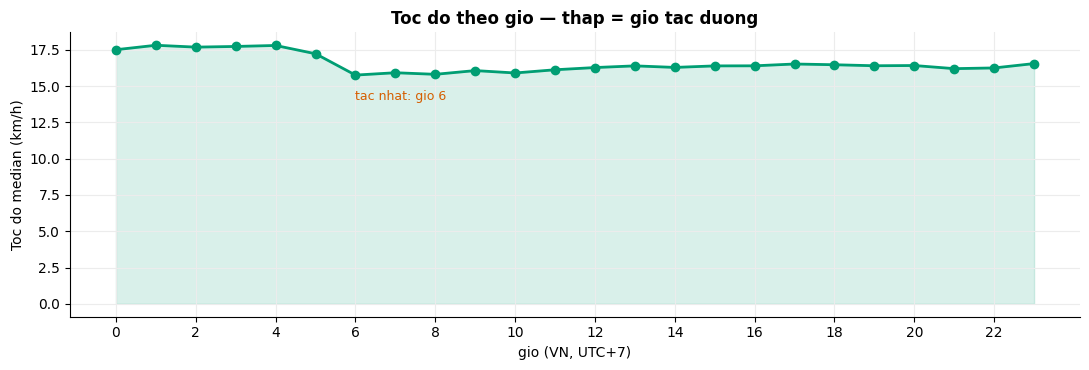

Tac nhat: gio 6 (15.8 km/h) | thong nhat: gio 1 (17.8 km/h)


In [4]:
sp = df.groupby("gio_vn").speed_kmh.median()
fig, ax = plt.subplots(figsize=(11,3.8))
ax.plot(sp.index, sp.values, marker="o", color=GREEN, lw=2)
ax.fill_between(sp.index, sp.values, alpha=.15, color=GREEN)
ax.set_xlabel("gio (VN, UTC+7)"); ax.set_ylabel("Toc do median (km/h)"); ax.set_xticks(range(0,24,2))
ax.set_title("Toc do theo gio — thap = gio tac duong", fontweight="bold")
lo, hi = sp.idxmin(), sp.idxmax()
ax.annotate(f"tac nhat: gio {lo}", (lo, sp[lo]), textcoords="offset points", xytext=(0,-18), color=RED, fontsize=9)
plt.tight_layout(); plt.show()
print(f"Tac nhat: gio {lo} ({sp[lo]:.1f} km/h) | thong nhat: gio {hi} ({sp[hi]:.1f} km/h)")

## 4. Tắc đường ↔ hệ số nhân

,surge_rate,surge_mean
tacbin,,
Thong,0.748,1.117
Hoi thong,0.791,1.144
TB,0.819,1.164
Hoi tac,0.847,1.186
Tac nang,0.878,1.215


eta(muc tac, SURGE)=0.195 | corr(phut/km, surge)=0.192


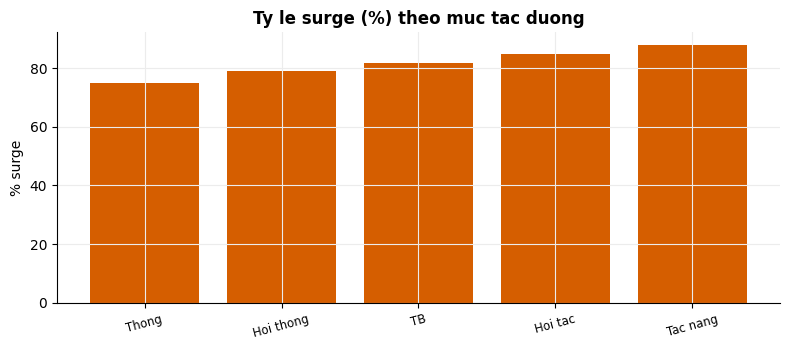

In [5]:
ts = df.groupby("tacbin").agg(surge_rate=("is_surge","mean"), surge_mean=(SURGE,"mean")).round(3)
display(ts)
print(f"eta(muc tac, SURGE)={eta(df.tacbin, df[SURGE]):.3f} | corr(phut/km, surge)={df.dur_per_km.corr(df[SURGE]):.3f}")
fig, ax = plt.subplots(figsize=(8,3.6))
ax.bar(range(len(ts)), ts.surge_rate*100, color=RED)
ax.set_xticks(range(len(ts))); ax.set_xticklabels(ts.index, rotation=15, fontsize=8.5)
ax.set_title("Ty le surge (%) theo muc tac duong", fontweight="bold"); ax.set_ylabel("% surge")
plt.tight_layout(); plt.show()

## Kết luận — Tắc đường

- **→ Giá:** tắc đường **làm tăng giá THẬT SỰ** — cùng quãng đường, chuyến tắc hơn thì đắt hơn
  (do thành phần cước tính theo phút). Đây chính là mắt xích Boston thiếu → gây "sàn nhiễu ~2 USD".
- **→ Hệ số nhân:** khu/giờ tắc thường đi kèm surge cao hơn (thị trường căng).
- 💡 Chứng minh trực tiếp giá trị của trường `quote_duration` mà nhóm đề xuất xin — model giá trên
  HCM kỳ vọng **vượt trần sàn nhiễu** của bộ Boston.